### Importing the Libraries.

In [1]:
import fastkde
from matplotlib import rcParams
import matplotlib.pyplot as plt
import pytometry as pt
import rapids_singlecell as rsc
import scanpy as sc
import scipy
import numpy as np
import seaborn as sns


# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


/home/icb/lorenzo.consoli/miniconda3/envs/rapids_singlecell/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reading the Data.

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the Data.

In [3]:
# optionally subsample the data
def get_adata_copy():
    SUBSAMPLE_SIZE = 1e-3
    adata_copy = adata.copy()
    sc.pp.subsample(adata_copy, SUBSAMPLE_SIZE)
    return adata_copy


### Applying logicle tranformation.

[2025-07-23 12:20:26.627] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-07-23 12:20:56.816] [CUML] [debug] n_neighbors=15
[2025-07-23 12:20:56.816] [CUML] [debug] Calling knn graph run
[2025-07-23 12:20:56.816] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-07-23 12:20:57.477] [CUML] [debug] Done. Calling remove zeros


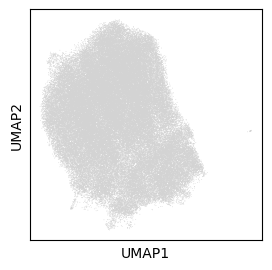

In [4]:
adata_copy = get_adata_copy()
pt.tl.normalize_logicle(adata_copy, inplace=True, a=5, w=1)
rsc.pp.pca(adata_copy, n_comps=20)
rsc.pp.neighbors(adata_copy)
rsc.tl.umap(adata_copy)
sc.pl.umap(adata_copy)


### Plotting the density for each channel.

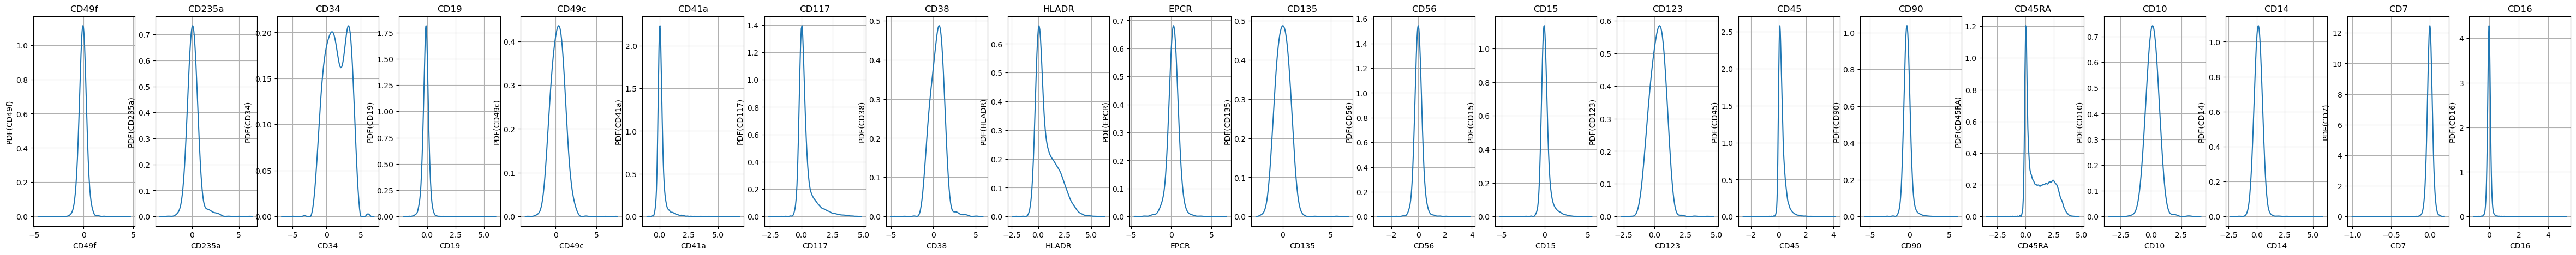

In [5]:
adata_copy = get_adata_copy()
pt.tl.normalize_arcsinh(adata_copy, cofactor=3000)
X_channel = adata_copy.X
fig, axes = plt.subplots(1, X_channel.shape[-1], figsize=(60, 5))
for idx, col in enumerate(adata.var_names): 
    fastkde.pdf(X_channel[:, idx], var_names=[col, ]).plot(ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].grid(True)
fig.show()


### Inspecting the CD90 antibody.

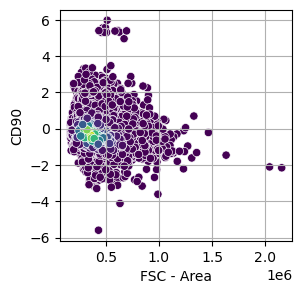

In [7]:
adata_copy = get_adata_copy()
pt.tl.normalize_arcsinh(adata_copy, cofactor=3000)
X = adata_copy.obs['FSC - Area'].values
Y = adata_copy.X[:, list(adata_copy.var_names).index('CD90')]
test_points = list(zip(X, Y))
values = np.vstack([X, Y])
kernel = scipy.stats.gaussian_kde(values)(values)

plt.figure()
sns.scatterplot(x=X,y=Y,c=kernel)
plt.xlabel('FSC - Area')
plt.ylabel('CD90')
plt.grid(True)


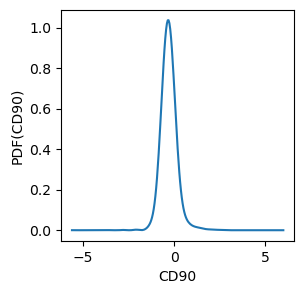

In [10]:
fastkde.pdf(Y, var_names=["CD90", ]).plot()


[2025-07-23 12:45:25.106] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-07-23 12:45:31.218] [CUML] [debug] n_neighbors=15
[2025-07-23 12:45:31.219] [CUML] [debug] Calling knn graph run
[2025-07-23 12:45:31.219] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-07-23 12:45:31.312] [CUML] [debug] Done. Calling remove zeros


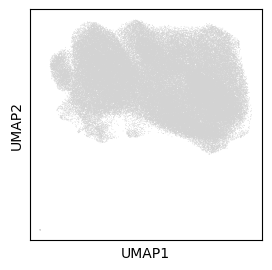

In [11]:
adata_copy = get_adata_copy()
pt.tl.normalize_arcsinh(adata_copy, cofactor=3000)
rsc.pp.pca(adata_copy, n_comps=20)
rsc.pp.neighbors(adata_copy)
rsc.tl.umap(adata_copy)
sc.pl.umap(adata_copy)
